# 10 - Experiment Splits (SPLIT1 / SPLIT2 / SPLIT3)

This notebook creates three data split variants with focus on class distribution across train/val/test.

Design choices used here:
- no signer-disjoint constraint,
- class-wise split allocation close to 80/10/10 for each label,
- SPLIT2 uses already normalized+augmented metadata from CSV,
- SPLIT3 uses validation sampled from SPLIT2 train while keeping SPLIT2 train and test unchanged.

In [1]:
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
plt.style.use('ggplot')

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

INPUT_SPLIT1_CSV = PROJECT_ROOT / 'merged_datasets' / 'universal_metadata_topn_classes.csv'
INPUT_SPLIT2_CSV = PROJECT_ROOT / 'merged_datasets' / 'universal_metadata_topn_videos_augmented.csv'

OUTPUT_SPLIT1_CSV = PROJECT_ROOT / 'merged_datasets' / 'split1_original_no_norm_no_aug.csv'
OUTPUT_SPLIT2_CSV = PROJECT_ROOT / 'merged_datasets' / 'split2_normalized_augmented.csv'
OUTPUT_SPLIT3_CSV = PROJECT_ROOT / 'merged_datasets' / 'split3_norm_aug_val_from_train.csv'

OUTPUT_STATS_SPLIT1_CSV = PROJECT_ROOT / 'merged_datasets' / 'split1_stats.csv'
OUTPUT_STATS_SPLIT2_CSV = PROJECT_ROOT / 'merged_datasets' / 'split2_stats.csv'
OUTPUT_STATS_SPLIT3_CSV = PROJECT_ROOT / 'merged_datasets' / 'split3_stats.csv'

RANDOM_SEED = 42
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

assert abs((TRAIN_RATIO + VAL_RATIO + TEST_RATIO) - 1.0) < 1e-9

print('INPUT_SPLIT1_CSV:', INPUT_SPLIT1_CSV, '| exists:', INPUT_SPLIT1_CSV.exists())
print('INPUT_SPLIT2_CSV:', INPUT_SPLIT2_CSV, '| exists:', INPUT_SPLIT2_CSV.exists())
print('RATIOS train/val/test:', TRAIN_RATIO, VAL_RATIO, TEST_RATIO)

INPUT_SPLIT1_CSV: C:\Users\kacpe\source\repos\szum\merged_datasets\universal_metadata_topn_classes.csv | exists: True
INPUT_SPLIT2_CSV: C:\Users\kacpe\source\repos\szum\merged_datasets\universal_metadata_topn_videos_augmented.csv | exists: True
RATIOS train/val/test: 0.8 0.1 0.1


In [3]:
def validate_required_columns(df: pd.DataFrame, required: list[str], name: str) -> None:
    missing = [c for c in required if c not in df.columns]
    if len(missing) > 0:
        raise ValueError(f'{name}: missing required columns: {missing}')


def classwise_split(
    df: pd.DataFrame,
    label_col: str = 'label',
    train_ratio: float = 0.8,
    val_ratio: float = 0.1,
    test_ratio: float = 0.1,
    seed: int = 42,
) -> pd.DataFrame:
    out = df.copy()
    out['split'] = ''

    rng = np.random.default_rng(seed)

    for label, group in out.groupby(label_col, sort=True):
        idx = group.index.to_numpy().copy()
        rng.shuffle(idx)
        n = len(idx)

        exact = np.array([train_ratio, val_ratio, test_ratio], dtype=float) * n
        base = np.floor(exact).astype(int)
        remain = n - int(base.sum())

        if remain > 0:
            order = np.argsort(-(exact - base))
            for j in order[:remain]:
                base[j] += 1

        n_train, n_val, n_test = int(base[0]), int(base[1]), int(base[2])

        out.loc[idx[:n_train], 'split'] = 'train'
        out.loc[idx[n_train:n_train + n_val], 'split'] = 'val'
        out.loc[idx[n_train + n_val:n_train + n_val + n_test], 'split'] = 'test'

    return out


def split_stats_table(df: pd.DataFrame, label_col: str = 'label') -> tuple[pd.DataFrame, pd.DataFrame]:
    split_stats = df.groupby('split').agg(
        n_rows=(label_col, 'size'),
        n_labels=(label_col, 'nunique'),
        n_augmented=('is_augmented', 'sum') if 'is_augmented' in df.columns else (label_col, lambda s: 0),
    )
    split_stats['pct_rows'] = (split_stats['n_rows'] / max(len(df), 1) * 100).round(2)

    class_counts = pd.crosstab(df[label_col], df['split'])
    class_props = class_counts.div(class_counts.sum(axis=1), axis=0).fillna(0.0)
    return split_stats, class_props


def plot_split_overview(df: pd.DataFrame, title: str, label_col: str = 'label', top_n_labels: int = 20) -> None:
    split_counts = df['split'].value_counts().reindex(['train', 'val', 'test']).fillna(0)

    class_counts = pd.crosstab(df[label_col], df['split'])
    class_props = class_counts.div(class_counts.sum(axis=1), axis=0).fillna(0.0)

    if len(class_props) > top_n_labels:
        top_labels = class_counts.sum(axis=1).sort_values(ascending=False).head(top_n_labels).index
        class_props_plot = class_props.loc[top_labels]
    else:
        class_props_plot = class_props

    fig, axes = plt.subplots(1, 2, figsize=(16, max(5, int(0.35 * len(class_props_plot)))))

    axes[0].bar(split_counts.index.astype(str), split_counts.values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    axes[0].set_title(f'{title} - sample counts by split')
    axes[0].set_xlabel('split')
    axes[0].set_ylabel('rows')

    mat = class_props_plot.reindex(columns=['train', 'val', 'test']).fillna(0.0).values
    im = axes[1].imshow(mat, aspect='auto', cmap='YlGnBu', vmin=0, vmax=1)
    axes[1].set_title(f'{title} - class proportions (top labels)')
    axes[1].set_xlabel('split')
    axes[1].set_ylabel(label_col)
    axes[1].set_xticks(np.arange(3))
    axes[1].set_xticklabels(['train', 'val', 'test'])
    axes[1].set_yticks(np.arange(len(class_props_plot.index)))
    axes[1].set_yticklabels(class_props_plot.index.astype(str))
    cbar = fig.colorbar(im, ax=axes[1])
    cbar.set_label('row share')

    plt.tight_layout()
    plt.show()

## SPLIT 1 - Original data (no normalization, no augmentation)

,n_rows,n_labels,n_augmented,pct_rows
split,,,,
test,160,30,0,9.71
train,1319,30,0,80.09
val,168,30,0,10.20


split,test,train,val
label,,,
again,0.096154,0.807692,0.096154
bird,0.098361,0.803279,0.098361
but,0.100000,0.800000,0.100000
cousin,0.092593,0.796296,0.111111
deaf,0.096154,0.807692,0.096154
doctor,0.098039,0.803922,0.098039
eat,0.104478,0.791045,0.104478
father,0.092593,0.796296,0.111111
finish,0.105263,0.789474,0.105263


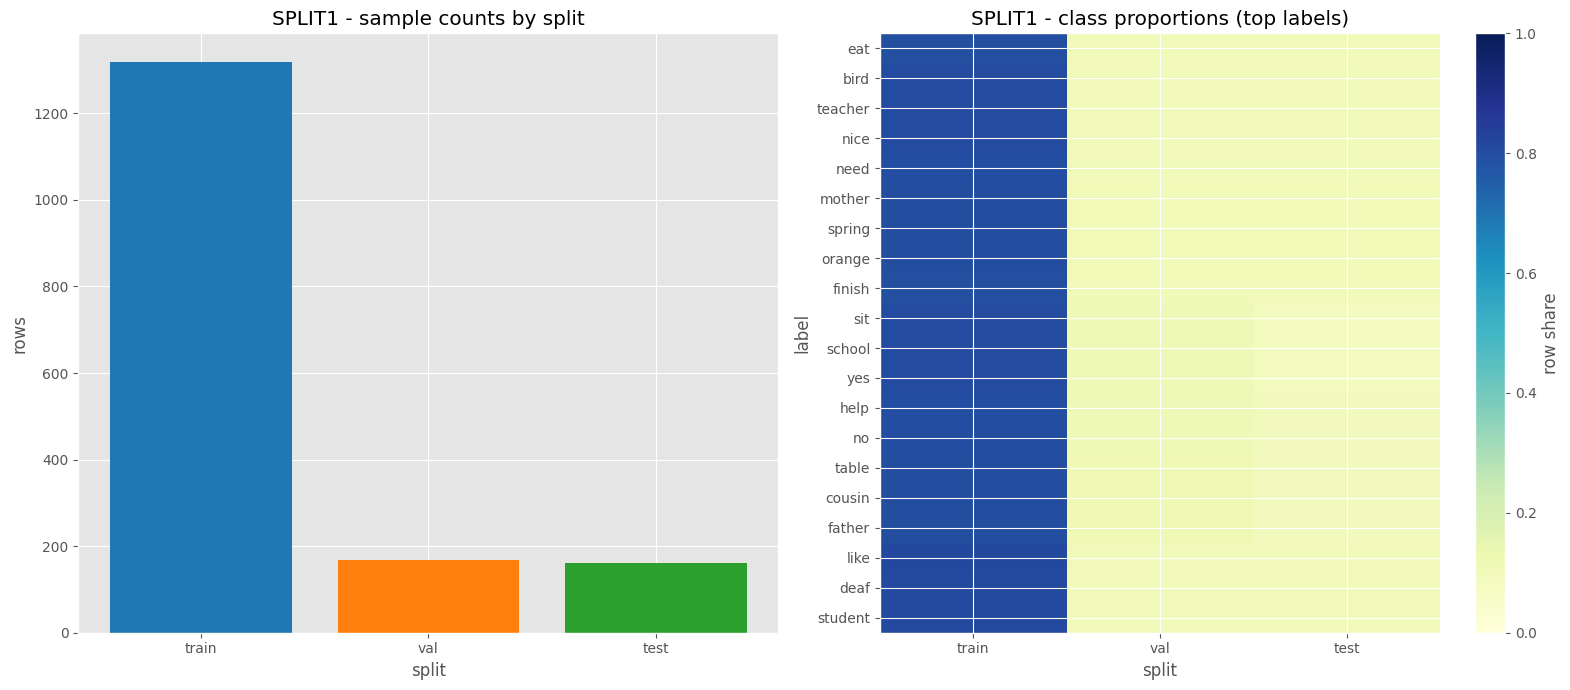

Saved SPLIT1: C:\Users\kacpe\source\repos\szum\merged_datasets\split1_original_no_norm_no_aug.csv
Saved SPLIT1 stats: C:\Users\kacpe\source\repos\szum\merged_datasets\split1_stats.csv


In [4]:
split1_df = pd.read_csv(INPUT_SPLIT1_CSV)
validate_required_columns(split1_df, ['label', 'video_path'], 'SPLIT1 input')

split1_df = split1_df.copy()
split1_df['is_augmented'] = False
split1_df['augmentation_name'] = 'original'

split1_df = classwise_split(
    split1_df,
    label_col='label',
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    seed=RANDOM_SEED,
)

split1_stats, split1_class_props = split_stats_table(split1_df, label_col='label')
display(split1_stats)
display(split1_class_props.head(15))
plot_split_overview(split1_df, 'SPLIT1', label_col='label', top_n_labels=20)

split1_df = split1_df.sort_values(['label', 'split']).reset_index(drop=True)
split1_df.to_csv(OUTPUT_SPLIT1_CSV, index=False)
split1_stats.to_csv(OUTPUT_STATS_SPLIT1_CSV)

print('Saved SPLIT1:', OUTPUT_SPLIT1_CSV)
print('Saved SPLIT1 stats:', OUTPUT_STATS_SPLIT1_CSV)

## SPLIT 2 - Normalized and augmented data

,n_rows,n_labels,n_augmented,pct_rows
split,,,,
test,2136,30,2010,9.98
train,17133,30,15777,80.02
val,2142,30,1977,10.00


split,test,train,val
label,,,
again,0.099112,0.800296,0.100592
bird,0.099622,0.800757,0.099622
but,0.100000,0.800000,0.100000
cousin,0.099715,0.800570,0.099715
deaf,0.099112,0.800296,0.100592
doctor,0.099548,0.800905,0.099548
eat,0.099885,0.800230,0.099885
father,0.099715,0.800570,0.099715
finish,0.099865,0.800270,0.099865


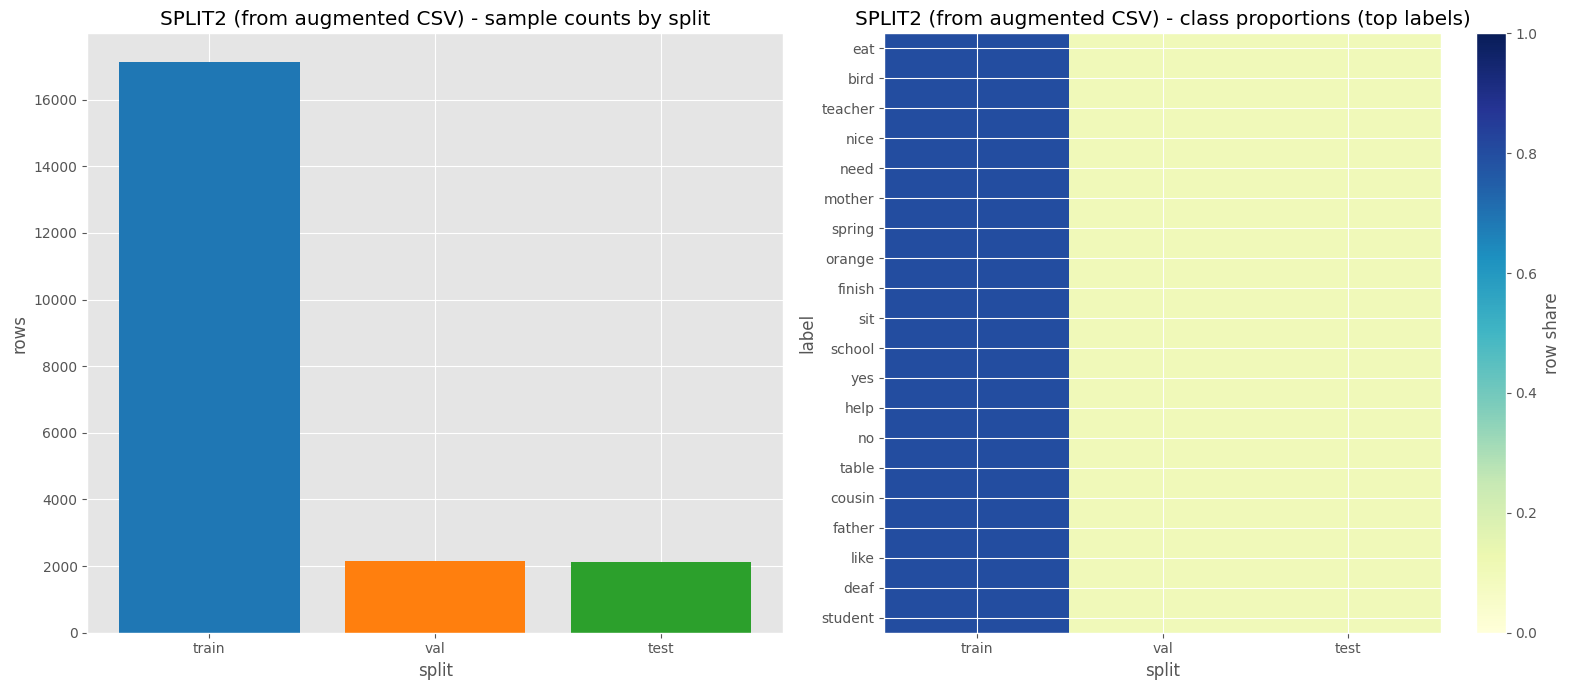

Saved SPLIT2: C:\Users\kacpe\source\repos\szum\merged_datasets\split2_normalized_augmented.csv
Saved SPLIT2 stats: C:\Users\kacpe\source\repos\szum\merged_datasets\split2_stats.csv


In [5]:
split2_input_df = pd.read_csv(INPUT_SPLIT2_CSV)
validate_required_columns(split2_input_df, ['label'], 'SPLIT2 input')

if 'process_status' in split2_input_df.columns:
    split2_input_df = split2_input_df[split2_input_df['process_status'] == 'ok'].copy()

split2_base = classwise_split(
    split2_input_df,
    label_col='label',
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    seed=RANDOM_SEED,
)

if 'is_augmented' not in split2_base.columns:
    split2_base['is_augmented'] = False
if 'augmentation_name' not in split2_base.columns:
    split2_base['augmentation_name'] = 'original'

split2_df = split2_base.copy()

split2_stats, split2_class_props = split_stats_table(split2_df, label_col='label')
display(split2_stats)
display(split2_class_props.head(15))
plot_split_overview(split2_df, 'SPLIT2 (from augmented CSV)', label_col='label', top_n_labels=20)

split2_df = split2_df.sort_values(['label', 'split', 'is_augmented']).reset_index(drop=True)
split2_df.to_csv(OUTPUT_SPLIT2_CSV, index=False)
split2_stats.to_csv(OUTPUT_STATS_SPLIT2_CSV)

print('Saved SPLIT2:', OUTPUT_SPLIT2_CSV)
print('Saved SPLIT2 stats:', OUTPUT_STATS_SPLIT2_CSV)

## SPLIT 3 - Like SPLIT2, but VAL sampled from SPLIT2 TRAIN

,n_rows,n_labels,n_augmented,pct_rows
split,,,,
test,2136,30,2010,9.98
train,17133,30,15777,80.02
val,2142,30,1993,10.00


split,test,train,val
label,,,
again,0.099112,0.800296,0.100592
bird,0.099622,0.800757,0.099622
but,0.100000,0.800000,0.100000
cousin,0.099715,0.800570,0.099715
deaf,0.099112,0.800296,0.100592
doctor,0.099548,0.800905,0.099548
eat,0.099885,0.800230,0.099885
father,0.099715,0.800570,0.099715
finish,0.099865,0.800270,0.099865


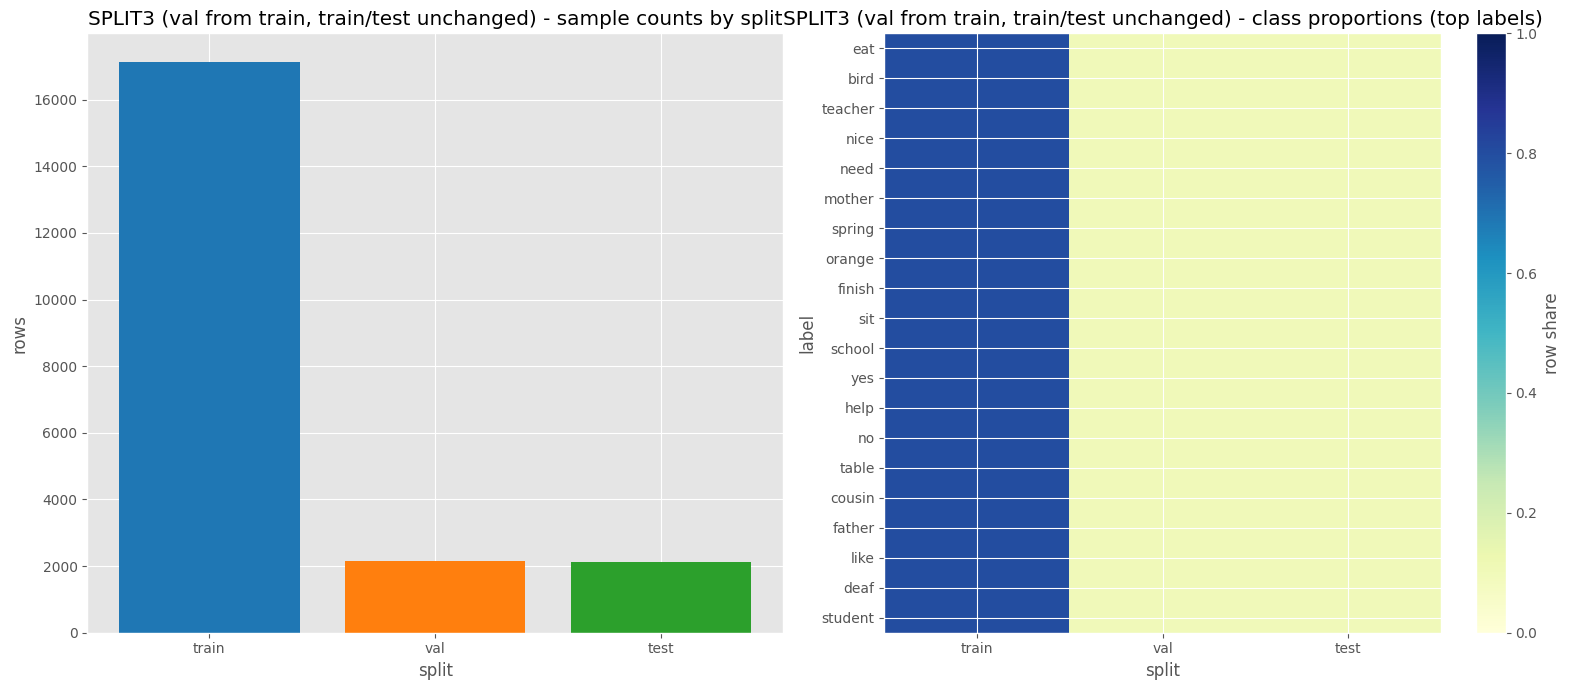

Saved SPLIT3: C:\Users\kacpe\source\repos\szum\merged_datasets\split3_norm_aug_val_from_train.csv
Saved SPLIT3 stats: C:\Users\kacpe\source\repos\szum\merged_datasets\split3_stats.csv


In [6]:
# Build SPLIT3 from SPLIT2 base (before augmentation).
# Requirement interpreted literally: keep SPLIT2 train and test unchanged,
# and replace validation with a subset sampled from SPLIT2 train.

rng = np.random.default_rng(RANDOM_SEED)

train2 = split2_base[split2_base['split'] == 'train'].copy()
val2 = split2_base[split2_base['split'] == 'val'].copy()
test2 = split2_base[split2_base['split'] == 'test'].copy()

target_val_counts = val2['label'].value_counts()

val3_parts = []
for label, n_target in target_val_counts.items():
    candidates = train2[train2['label'] == label]
    if len(candidates) == 0:
        continue

    n_take = min(int(n_target), len(candidates))
    take_idx = rng.choice(candidates.index.to_numpy(), size=n_take, replace=False)
    chunk = candidates.loc[take_idx].copy()
    chunk['split'] = 'val'
    val3_parts.append(chunk)

if len(val3_parts) > 0:
    val3 = pd.concat(val3_parts, ignore_index=True)
else:
    val3 = train2.head(0).copy()

train3 = train2.copy()
train3['split'] = 'train'
test3 = test2.copy()
test3['split'] = 'test'

split3_base = pd.concat([train3, val3, test3], ignore_index=True)
if 'is_augmented' not in split3_base.columns:
    split3_base['is_augmented'] = False
if 'augmentation_name' not in split3_base.columns:
    split3_base['augmentation_name'] = 'original'

split3_df = split3_base.copy()

split3_stats, split3_class_props = split_stats_table(split3_df, label_col='label')
display(split3_stats)
display(split3_class_props.head(15))
plot_split_overview(split3_df, 'SPLIT3 (val from train, train/test unchanged)', label_col='label', top_n_labels=20)

split3_df = split3_df.sort_values(['label', 'split', 'is_augmented']).reset_index(drop=True)
split3_df.to_csv(OUTPUT_SPLIT3_CSV, index=False)
split3_stats.to_csv(OUTPUT_STATS_SPLIT3_CSV)

print('Saved SPLIT3:', OUTPUT_SPLIT3_CSV)
print('Saved SPLIT3 stats:', OUTPUT_STATS_SPLIT3_CSV)

## Quick comparison table (SPLIT1 vs SPLIT2 vs SPLIT3)

In [7]:
def flatten_stats(stats_df: pd.DataFrame, name: str) -> pd.DataFrame:
    out = stats_df.copy().reset_index().rename(columns={'index': 'split'})
    out.insert(0, 'split_version', name)
    return out

cmp_df = pd.concat([
    flatten_stats(split1_stats, 'SPLIT1'),
    flatten_stats(split2_stats, 'SPLIT2'),
    flatten_stats(split3_stats, 'SPLIT3'),
], ignore_index=True)

display(cmp_df.sort_values(['split_version', 'split']))

,split_version,split,n_rows,n_labels,n_augmented,pct_rows
0,SPLIT1,test,160,30,0,9.71
1,SPLIT1,train,1319,30,0,80.09
2,SPLIT1,val,168,30,0,10.20
3,SPLIT2,test,2136,30,2010,9.98
4,SPLIT2,train,17133,30,15777,80.02
5,SPLIT2,val,2142,30,1977,10.00
6,SPLIT3,test,2136,30,2010,9.98
7,SPLIT3,train,17133,30,15777,80.02
8,SPLIT3,val,2142,30,1993,10.00
